In [ ]:
# TensorFlow and tf.keras
import tensorflow as tf
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
print(tf.__version__)

2.19.0


In [ ]:
# Importing the mnist dataset

fashion_mnist = tf.keras.datasets.fashion_mnist

# Splitting the dataset

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Actual Images
train_images.shape

(60000, 28, 28)

In [ ]:
train_labels.shape

(60000,)

In [ ]:
test_images.shape

(10000, 28, 28)

In [ ]:
test_labels.shape

(10000,)

In [ ]:
print(train_labels)


[9 0 0 ... 3 0 5]


In [ ]:
print(test_labels)

[9 2 1 ... 8 1 5]


In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',

               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

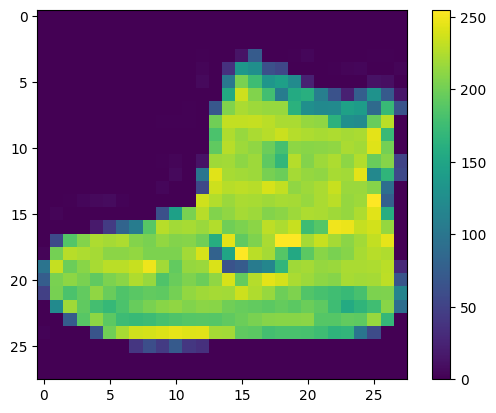

In [ ]:
plt.figure()

plt.imshow(train_images[0])

plt.colorbar()

plt.grid(False)

plt.show()

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. It's important that the training set and the testing set be preprocessed in the same way:

A data preprocessing technique that transforms the numerical features of a dataset to a similar range. This is done to ensure that no single feature dominates the learning process due to differences in their scales, leading to improved model performance and faster convergence.

Scaling is used to optimize the training process to handle large datasets and complex models efficiently to improve model stability and performance

If you relate it to Tabular Data - We used Z score to normalize and standardize the data to get accurate result - Specially in KNN and KMeans which are distance based algorithms

In [ ]:
train_images = train_images / 255.0



test_images = test_images / 255.0

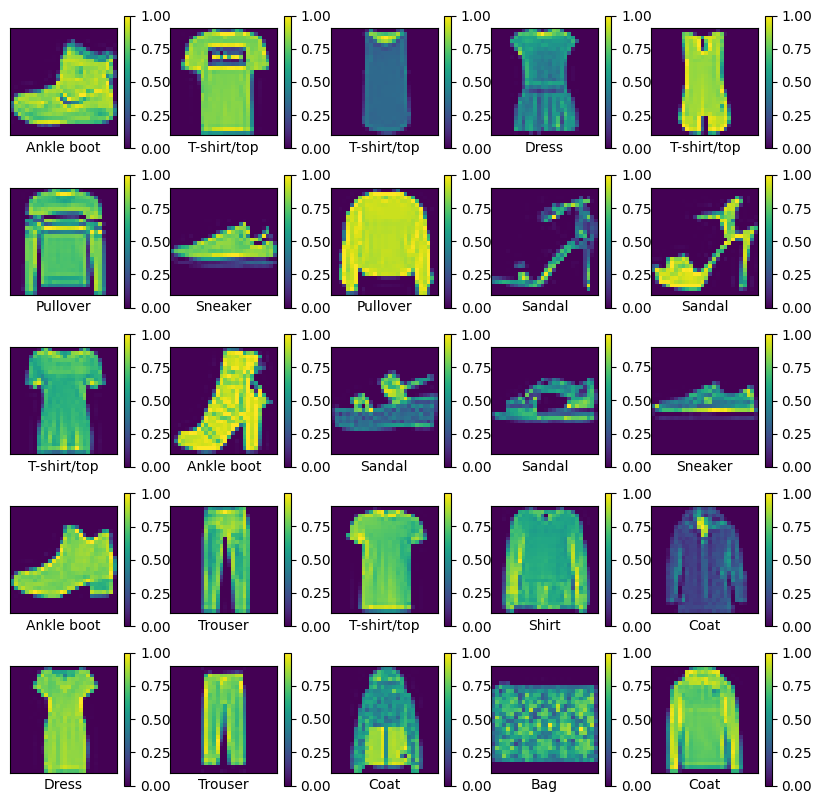

In [ ]:
plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.xticks([])

    plt.yticks([])

    plt.grid(False)

    #plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.imshow(train_images[i])
    plt.colorbar()

    plt.xlabel(class_names[train_labels[i]])

plt.show()

Build Model
1. Configure the models
2. Compile the model --> Mathmatical calculation
3. Feed the Data, Train the model with data

In [ ]:

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10)

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

tf.keras.layers.Flatten(input_shape=(28, 28))
The Flatten layer reshapes the input tensor into a 1-dimensional array (a vector) without affecting the batch size.
The input_shape argument specifies the shape of the input data that this layer expects, excluding the batch dimension. In this case, (28, 28) indicates that the input to this Flatten layer will be a 2-dimensional tensor with a height of 28 and a width of 28.
If the input to this Flatten layer has a shape like (batch_size, 28, 28), the Flatten layer will transform it into a shape of (batch_size, 784), where 784 is the result of 28 * 28. Each 28x28 image is effectively "unrolled" into a single vector of 784 elements.

tf.keras.layers.Dense(128, activation='relu')
This is a Keras layer that implements a densely connected (also known as fully connected) neural network layer. In a dense layer, every neuron in the layer receives input from all neurons in the previous layer.
128:
This argument specifies the units, which is the dimensionality of the output space of the layer. In simpler terms, it defines the number of neurons or nodes in this particular dense layer.
activation='relu':
This argument specifies the activation function to be applied to the output of the layer.
ReLU (Rectified Linear Unit): The ReLU activation function is defined as f(x) = max(0, x). This means it outputs the input directly if it is positive, and outputs zero if the input is negative. ReLU is a popular choice for hidden layers in neural networks due to its computational efficiency and its ability to help mitigate the vanishing gradient problem.

tf.keras.layers.Dense(10)
tf.keras.layers.Dense accepts an input "units" and rest all have default values.

If only "units" then this signifies output layer.

units-  Positive integer, dimensionality of the output space.

Why are we doing this?

The output needs to be classified into one of the 10 classes so, only "10" is passed here.

How are we doing this?

output arrays is of shape (None, 10). so only the name of concerned class (which the model has classified) is returned.

For CNN we used Conv2D, we can use 32 filters of size 3 x 3 and MaxPooling2D layers which reduces the spatial dimensions of the feature maps to reduce computation and prevent overfitting

In [ ]:
model.compile(optimizer='adam',

              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),

              metrics=['accuracy'])

# 1- What is Optimiser and Why adam ?

# ---

# Optimizer is step used to minimize Loss from adjusting Input with Weights.

# Adam optimizer is Combination of Root Mean Square Prop and Momentum

# (Minimum batch gradient descent) optimzers

# 2- What is loss function and why Crossentropy ?

# ---

# the Loss function is a method of evaluating how well your algorithm

# is modeling your dataset.

# It is a mathematical function of the parameters of the machine learning algorithm.





# It measures the inconsistency between predicted and actual outcomes,

# guiding the model towards accuracy in the followup iteration (epochs)



# Cross-entropy is widely used as a loss function when optimizing classification models.

# Two examples that you may encounter include the

# logistic regression algorithm (a linear classification algorithm),

# and artificial neural networks that can be used for classification tasks

# Types of optimizers: Gradient Descent,

#     Stochastic Gradient Descent,

#     Mini-batch Gradient Descent,

#     Adagrad, RMS Prop, AdaDelta



# 3- What is metrics and what are the other options could have ?
# ---



# We need to evaluate its performance.

# You can use different metrics, such as mean absolute error (MAE),

# root mean squared error (RMSE), or mean absolute percentage error (MAPE),

# to measure how close your predictions are to the actual values.



# Here we used Accuracy method which implies to  Measures the proportion of correctly

# classified instances out of the total instances.

In [ ]:
history = model.fit(train_images, train_labels, epochs=2, validation_data=(test_images, test_labels))

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.7769 - loss: 0.6274 - val_accuracy: 0.8755 - val_loss: 0.3439
Epoch 2/2
1613/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8842 - loss: 0.3178

313/313 - 1s - loss: 0.4340 - accuracy: 0.9109 - 790ms/epoch - 3ms/step


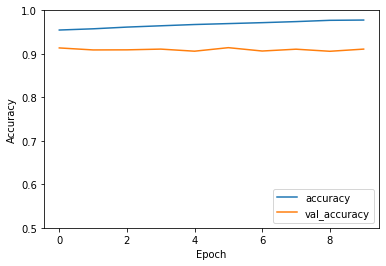

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)



print('\nTest accuracy:', test_acc)

313/313 - 1s - loss: 0.4340 - accuracy: 0.9109 - 765ms/epoch - 2ms/step

Test accuracy: 0.9108999967575073


In [ ]:
probability_model=tf.keras.Sequential([model,tf.keras.layers.Softmax()])

In [ ]:
predictions = probability_model.predict(test_images)

313/313 [==============================] - 1s 2ms/step


In [ ]:
predictions[0]

array([4.57634223e-06, 1.96206518e-09, 7.73097568e-08, 1.29620792e-09,
       1.00116075e-08, 2.40173991e-04, 8.82300299e-07, 1.03482173e-03,
       1.89313550e-06, 9.98717666e-01], dtype=float32)